<a href="https://colab.research.google.com/github/psalazarec/TestPython/blob/main/Actividad1_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 1: red MLP

### **Construye una red Perceptrón Multicapa para clasificar imágenes de ropa en escala de grises, del dataset Fashion MNIST.**

El dataset FashionMNIST esta formado por imágenes del mismo tamaño y canales que las del dataset MNIST original de números escritos a mano, por lo que puede usarse gran parte del código del ejercicio resuelto MNIST_MLP como ayuda.

Los criterios de evaluación pueden ser consultados en la rúbrica de la actividad. Sólo una propuesta de red y ejecución de entrenamiento debe ser entregada. Por supuesto, os animo a que probéis distintas configuraciones de red y entrenamiento, pero la entrega debe ser sólo con vuestro mejor resultado.

Si te surgen problemas, aconsejo partir de la red del ejercicio resuelto y tocar poco a poco parámetros, para ver que efecto tienen. Si te atascas, no dudes en publicar tus dudas en el tablon para que otros alumnos o el profesor te pueda ayudar.

Añado el codigo de inicializacion de Pytorch, de carga de la base de datos FashionMNIST, y de pintar unas imagenes para comprobar que se ha cargado correctamente.

**La entrega de la actividad será el archivo del cuaderno de Jupyter (archivo .ipynb). Puede descargarse desde Archivo > Descargar > Descargar .ipynb**

In [1]:
!pip install torchview

In [2]:
# importamos la libreria pytorch
import torch
from torch import nn
from torch import optim #las funciones de optimizacion (gradient descent)
from torch.optim.lr_scheduler import StepLR #learning rate decay
import torch.nn.functional as F #convencion
from torchvision import datasets, transforms

# matplotlib para pintar graficas
import matplotlib.pyplot as plt
%matplotlib inline

from torchview import draw_graph
import graphviz

In [3]:
# usamos la GPU si esta disponible
if torch.cuda.is_available():
  device = torch.device("cuda")
  print("Dispositivo usado: GPU con CUDA")
else:
  device = torch.device("cpu")
  print("Dispositivo usado: CPU")

Dispositivo usado: CPU


In [4]:
# Definir una transformación para convertir la imagen a un tensor
transform=transforms.Compose([
    transforms.ToTensor(), # hay que convertir a tensor los datos
    transforms.Normalize((0.2860,), (0.3530,)) # normalizacion del dataset
    ])

# Descargar el dataset FashionMNIST de articulos de ropa
dataset_train = datasets.FashionMNIST('data', train=True, download=True, transform=transform)
dataset_test = datasets.FashionMNIST('data', train=False, download=True, transform=transform)

# la media y desviacion del dataset son los valores por los que se normaliza
# es buena idea normalizar el dataset para ayudar a que converja mas rapido
print("media: ", dataset_train.data.float().mean()/255)
print("desviacion: ", dataset_train.data.float().std()/255)

# tamaño del mini-batch
batch_size = 64
train_kwargs = {'batch_size': batch_size}
test_kwargs = {'batch_size': batch_size}

# generamos los dataloaders que se usaran para leer
# las imagenes el entrenamiento y test
train_loader = torch.utils.data.DataLoader(dataset_train, **train_kwargs)
test_loader = torch.utils.data.DataLoader(dataset_test, **test_kwargs)

# categoria de ropa que corresponde a cada numero
desc = ['Camiseta/top', 'Pantalon', 'Jersey', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 277kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.3MB/s]


media:  tensor(0.2860)
desviacion:  tensor(0.3530)


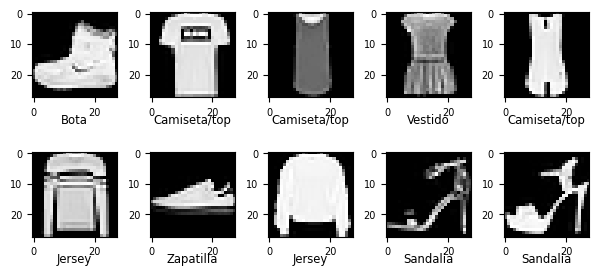

In [5]:
import matplotlib.pyplot as plt

# primero, vemos unas imagenes del set de entrenamiento con sus etiquetas (labels)
figure = plt.figure(figsize=(6, 3)) # Adjusted figure size for 2 rows of 5 images

# configurar tamaño de texto para las graficas
plt.rc('font', size=7)

for i in range(0,10):
  figure.add_subplot(2, 5, i+1) # Changed to 2 rows, 5 columns
  img, label = dataset_train[i]

  # img tiene dimensiones [1,28,28], squeeze() destruye las dimensiones de tamaño 1
  plt.imshow(img.squeeze(), cmap='Greys_r')
  #plt.axis('off')
  plt.title(desc[label], y=-0.4)
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show() # Display the plot

In [6]:
# Definicion de la red neuronal

# Tamaño de entrada, en este caso el tamaño
# de las imagenes de entrada: 28*28 = 784
input_size = 784 # @param {type:"integer"}

# Tamaño de salida (número de clases en un problema de clasificación)
# en este caso hay 10 clases (números del 0 al 9)
output_size = len(desc)
activation_function_option = "ReLU" # @param ["ReLU", "Sigmoid", "Tanh"]

# Tamaño de la capa oculta
hidden_size = 30 # @param {type:"integer"}

# Definir la arquitectura de la red MLP
class MLP(nn.Module):

    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) # capa fully connected
        self.relu = nn.ReLU() # el mismo relu para fc1 y fc2
        self.sigmoid = nn.Sigmoid() # Añadimos la función Sigmoid
        self.tanh = nn.Tanh() # Añadimos la función Tanh
        self.fc2 = nn.Linear(hidden_size, output_size) # capa fully connected
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x);
        # Aplicar la función de activación seleccionada por la variable global
        if activation_function_option == "ReLU":
            x = self.relu(x)
        elif activation_function_option == "Sigmoid":
            x = self.sigmoid(x)
        elif activation_function_option == "Tanh":
            x = self.tanh(x)

        x = self.fc2(x)
        x = self.softmax(x)
        return x

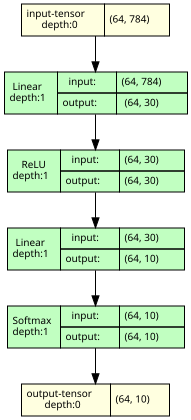

In [7]:
# diagrama con la arquitectura de red
model = MLP()
model_graph = draw_graph(model, input_size=(batch_size, input_size))
model_graph.visual_graph

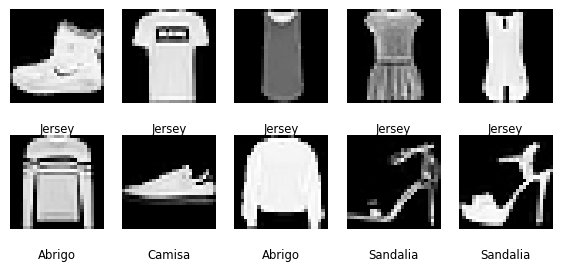

In [8]:
# Como se comporta la red neuronal antes de entrenar?

# primero, inicializamos el generador de numeros aleatorios
# con una semilla, para obtener resultados deterministas
torch.manual_seed(42)

# Creamos una instancia del modelo
model = MLP()
model.to(device)

# generamos un grafico para representar las imagenes
figure = plt.figure(figsize=(7, 3))

for i in range(0,10):

  # calculamos la salida del modelo con los parametros iniciales aleatorios
  input = dataset_train.data[i].view(1, 28*28).float().to(device)
  output = model(input)

  # de las diez neuronas de salida, la que tenga
  # mayor valor corresponde a la prediccion del modelo
  pred = output.argmax(dim=1, keepdim=True)


  # graficamos el resultado
  figure.add_subplot(2, 5, i+1)
  plt.axis('off')
  plt.imshow(dataset_train.data[i], cmap='Greys_r')
  plt.title(desc[pred.item()], y=-0.4)

In [9]:
# funcion de entrenamiento
def train(model):

    # configurar el modelo en modo entrenamiento
    # se necesita para que capas como batchnorm o dropout se comporten correctamente
    model.train()

    # iteramos por los mini-batches del set de entrenamiento
    for batch_idx, (data, target) in enumerate(train_loader):

        # mandamos los datos al dispositivo (necesario cuando se usa la GPU)
        data, target = data.to(device), target.to(device)

        # calculamos la salida del modelo (prediccion)
        output = model(data.view(data.shape[0], 28*28)) # la entrada es un tensor [batch_size, 28*28]

        # definimos la funcion de perdida como el error cuadratico medio
        # como la prediccion del modelo es un vector de 10 elementos (las 10 neuronales finales)
        # hay que convertir la label del set de entrenamiento en un vector
        # con el valor correspondiente 1 y todos los demas valores 0 (un vector one-hot)
        target_onehot = F.one_hot(target, num_classes=10).float()
        loss = F.mse_loss(output, target_onehot)

        # se ejecuta el backpropagation para calcular el gradiente
        loss.backward()

        # se guarda el historico de la perdida para graficarlo
        loss_training.append(loss.item())

        # se actualizan los pesos y sesgos de la red
        optimizer.step()

        # se resetean a cero los gradientes
        optimizer.zero_grad()

        # cada 50 mini-batches, imprimimos por pantalla la perdida
        print_interval = 50
        if batch_idx % print_interval == 0:
            print('   Loss: ', loss.item())

    print('Training Epoch completa\n')

In [10]:
# funcion de test
def test(model, split):

    # podemos ejecutar el test sobre el split de test o el training
    # asi vemos despues si tenemos overfitting
    if split == 'train':
        loader = train_loader
        loss_history = loss_train_split
    else:
        loader = test_loader
        loss_history = loss_test_split

    # configurar el modelo en modo evaluacion o inferencia
    # se necesita para que capas como batchnorm o dropout se comporten correctamente
    model.eval()

    # lista para almacenar los fallos,
    # global para que se pueda consultar fuera de la funcion
    global errorList
    errorList = []
    correct = 0
    test_loss = 0

    # durante el test solo hacemos el forward pass y no necesitamos los gradientes
    with torch.no_grad():
        for data, target in loader:

            # mandamos los datos al dispositivo (necesario cuando se usa la GPU)
            data, target = data.to(device), target.to(device)

            # calculamos la salida del modelo (prediccion)
            output = model(data.view(data.shape[0], 28*28))
            target_onehot = F.one_hot(target, num_classes=10).float()

            # suma acumulada de la pérdida
            test_loss += F.mse_loss(output, target_onehot, reduction='sum')

            # de las diez neuronas de salida, la que tenga
            # mayor valor corresponde a la prediccion del modelo
            pred = output.argmax(dim=1, keepdim=True)

            # si la prediccion es igual al valor etiquetado, se cuenta como correcto
            correct += pred.eq(target.view_as(pred)).sum().item()

            # los que no sean iguales al valor etiquetado,
            # se meten en un array de errores
            for index, error in enumerate(pred.ne(target.view_as(pred))):
              if (error):
                errorList.append({
                    "data": data[index],
                    "pred": pred[index],
                    "target": target[index]
                    })

    # se divide el acumulado de la perdida por el tamaño del dataset
    # para obtener la media de la perdida
    # se divide tambien por 10, que es el tamaño del one-hot vector (el numero de clases)
    test_loss /= len(loader.dataset)*10

    # se guarda el historico de la perdida en el test para graficarlo
    loss_history.append(test_loss.item())

    # imprimir por pantalla los resultados del test
    print('Test (split ', split,
          '):\n   Loss medio: ', test_loss.item(),
          'Errores: ',  len(errorList),
          'Precision: ', 100 * correct / len(loader.dataset), '%\n')


In [11]:
# ejecutamos un test antes de empezar el entrenamiento
# la precision debe ser sobre el 10% (como hay 10 etiquetas,
# 1 de cada 10 el modelo acertara)
model = MLP()
model.to(device)
loss_test_split = []
test(model, 'test')

Test (split  test ):
   Loss medio:  0.09069069474935532 Errores:  9299 Precision:  7.01 %



In [ ]:
# entrenamos la red

# semilla del generador de numeros aleatorios
# para conseguir resultados deterministas
torch.manual_seed(42)

# lista para graficar la perdida de entrenamiento y test
loss_training = []
loss_test_split = []
loss_train_split = []

# Crear una instancia del modelo y pasarla al dispositivo
model = MLP()
model.to(device)

# optimizador, mini-batch gradient descent
# (en pytorch le llaman stochastic gradient descent, pero es un mini-batch gradient descent)
optimizer = optim.SGD(model.parameters(), lr=1.0)

# learning rate decay, se multiplica por gamma cada step_size steps
scheduler = StepLR(optimizer, step_size=1, gamma=0.7)

epochs = 10
for epoch in range(0, epochs):
    print('Epoch:', epoch, 'LR:', scheduler.get_last_lr())
    train(model)
    test(model, 'test')
    test(model, 'train')
    scheduler.step()


Epoch: 0 LR: [1.0]
   Loss:  0.08883599936962128
   Loss:  0.04462110996246338
   Loss:  0.0363195538520813
   Loss:  0.038208797574043274
   Loss:  0.021391447633504868
   Loss:  0.03755820915102959
   Loss:  0.035068560391664505
   Loss:  0.014080601744353771
   Loss:  0.03456113860011101
   Loss:  0.02531222067773342
   Loss:  0.02911682054400444
   Loss:  0.01795274391770363
   Loss:  0.026153260841965675
   Loss:  0.032094262540340424
   Loss:  0.02740071713924408
   Loss:  0.023552490398287773
   Loss:  0.030619177967309952
   Loss:  0.02308892086148262
   Loss:  0.02578926645219326
Training Epoch completa

Test (split  test ):
   Loss medio:  0.025396106764674187 Errores:  1760 Precision:  82.4 %

Test (split  train ):
   Loss medio:  0.02344334125518799 Errores:  9716 Precision:  83.80666666666667 %

Epoch: 1 LR: [0.7]
   Loss:  0.019372375681996346
   Loss:  0.024652816355228424
   Loss:  0.022689828649163246
   Loss:  0.025910258293151855
   Loss:  0.016153985634446144
   Los

In [ ]:
# graficamos la perdida durante el entrenamiento
plt.plot(loss_training)

In [ ]:
# pintamos algunas predicciones
figure = plt.figure(figsize=(8, 8))

for i in range(0,15):

  # calcula la salida del modelo con los parametros entrenados
  input = dataset_train.data[i].resize(1, 28*28).float().to(device)
  output = model(input)

  # de las diez neuronas de salida, la que tenga
  # mayor valor corresponde a la prediccion del modelo
  pred = output.argmax(dim=1, keepdim=True)

  # pintamos la imagen y la prediccion del modelo
  figure.add_subplot(3, 5, i+1)
  plt.axis('off')
  plt.imshow(dataset_train.data[i], cmap='Greys_r')
  plt.title("pred:" + str(desc[pred.item()]), y=-0.4)